In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

print("All libraries loaded ✅")

/Users/krishnachauhan/Projects/nlp-sentiment-analysis/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All libraries loaded ✅


In [2]:
print("Loading multi-class sentiment model...")

sentiment_pipeline = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

print("Model loaded ✅")

# Quick test
test = sentiment_pipeline("This product is absolutely amazing!")
print(f"\nTest result: {test}")

Loading multi-class sentiment model...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Model loaded ✅

Test result: [{'label': 'positive', 'score': 0.8328792452812195}]


In [3]:
reviews = [
    "This product exceeded all my expectations, absolutely love it!",
    "Terrible quality, broke after just two days of use.",
    "Decent product for the price, nothing extraordinary.",
    "Amazing customer service and fast delivery, highly recommend!",
    "Very disappointed, the product looks nothing like the pictures.",
    "Good value for money, works exactly as described.",
    "Worst purchase I have ever made, complete waste of money.",
    "Outstanding quality and beautiful design, worth every penny!",
    "Average product, does the job but nothing special.",
    "Fantastic! Exceeded expectations in every way possible.",
    "Poor build quality, feels very cheap and flimsy.",
    "Really happy with this purchase, will definitely buy again.",
    "Not what I expected, quite disappointed with the quality.",
    "Excellent product, fast shipping and great packaging too!",
    "Mediocre at best, there are better options available.",
    "Love this product! It has made my life so much easier.",
    "Horrible experience, customer service was unhelpful too.",
    "Pretty good overall, minor issues but nothing deal-breaking.",
    "Best product in this category, highly recommend to everyone!",
    "Completely useless, does not work as advertised at all."
]

categories = [
    'Electronics', 'Electronics', 'Electronics', 'Clothing', 'Clothing',
    'Clothing', 'Home', 'Home', 'Home', 'Beauty',
    'Beauty', 'Beauty', 'Sports', 'Sports', 'Sports',
    'Kitchen', 'Kitchen', 'Kitchen', 'Books', 'Books'
]

df = pd.DataFrame({'review': reviews, 'category': categories})
print(f"Dataset created: {df.shape}")
df.head()

Dataset created: (20, 2)


,review,category
0,"This product exceeded all my expectations, abs...",Electronics
1,"Terrible quality, broke after just two days of...",Electronics
2,"Decent product for the price, nothing extraord...",Electronics
3,"Amazing customer service and fast delivery, hi...",Clothing
4,"Very disappointed, the product looks nothing l...",Clothing


In [4]:
print("Analyzing all reviews...")

# All 3 classes ke scores nikalo
results = sentiment_pipeline(reviews, return_all_scores=True)

# Extract labels and scores
sentiments = []
positive_pct = []
negative_pct = []
neutral_pct = []

for result in results:
    scores = {r['label']: round(r['score'] * 100, 2) for r in result}
    best_label = max(result, key=lambda x: x['score'])['label']
    sentiments.append(best_label)
    positive_pct.append(scores.get('positive', 0))
    negative_pct.append(scores.get('negative', 0))
    neutral_pct.append(scores.get('neutral', 0))

df['sentiment'] = sentiments
df['positive_%'] = positive_pct
df['negative_%'] = negative_pct
df['neutral_%'] = neutral_pct
df['confidence'] = df[['positive_%', 'negative_%', 'neutral_%']].max(axis=1)

print("Analysis Complete ✅")
print(f"\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nAverage Confidence: {df['confidence'].mean():.2f}%")
df[['review', 'sentiment', 'positive_%', 'negative_%', 'neutral_%']].head(10)

Analyzing all reviews...
Analysis Complete ✅

Sentiment Distribution:
sentiment
positive    11
negative     9
Name: count, dtype: int64

Average Confidence: 93.36%


,review,sentiment,positive_%,negative_%,neutral_%
0,"This product exceeded all my expectations, abs...",positive,98.79,0.46,0.75
1,"Terrible quality, broke after just two days of...",negative,0.79,94.31,4.90
2,"Decent product for the price, nothing extraord...",positive,90.71,1.98,7.30
3,"Amazing customer service and fast delivery, hi...",positive,97.77,0.83,1.41
4,"Very disappointed, the product looks nothing l...",negative,0.93,92.94,6.13
5,"Good value for money, works exactly as described.",positive,89.66,1.24,9.11
6,"Worst purchase I have ever made, complete wast...",negative,0.90,95.20,3.90
7,"Outstanding quality and beautiful design, wort...",positive,97.53,0.81,1.66
8,"Average product, does the job but nothing spec...",negative,2.61,72.43,24.95
9,Fantastic! Exceeded expectations in every way ...,positive,98.74,0.44,0.82


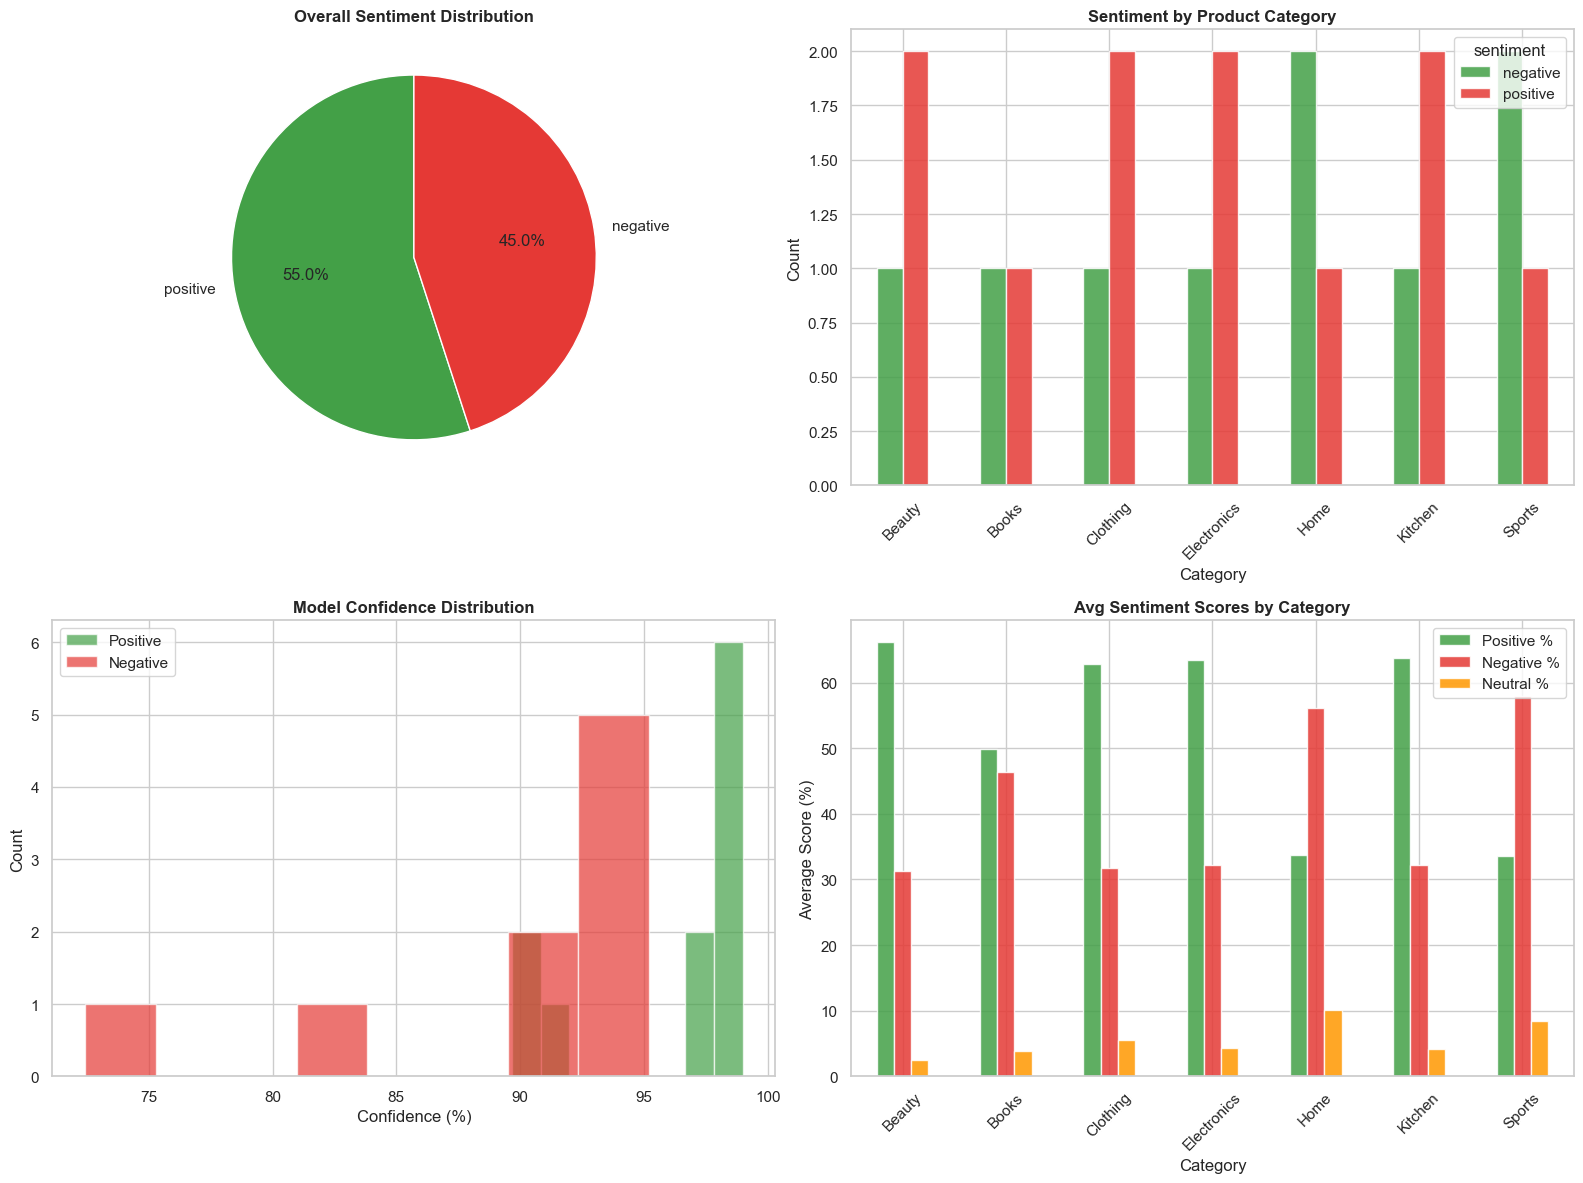

Visualizations saved ✅


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 - Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts()
colors = ['#43A047', '#E53935', '#FF9800']
axes[0,0].pie(sentiment_counts, labels=sentiment_counts.index,
              autopct='%1.1f%%', 
              colors=colors[:len(sentiment_counts)],
              startangle=90)
axes[0,0].set_title('Overall Sentiment Distribution', fontweight='bold')

# Plot 2 - Sentiment by Category
cat_sentiment = df.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
cat_sentiment.plot(kind='bar', ax=axes[0,1], 
                   color=['#43A047', '#E53935'], alpha=0.85)
axes[0,1].set_title('Sentiment by Product Category', fontweight='bold')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Confidence Distribution
axes[1,0].hist(df[df['sentiment']=='positive']['confidence'],
               bins=8, color='#43A047', alpha=0.7, label='Positive')
axes[1,0].hist(df[df['sentiment']=='negative']['confidence'],
               bins=8, color='#E53935', alpha=0.7, label='Negative')
axes[1,0].set_title('Model Confidence Distribution', fontweight='bold')
axes[1,0].set_xlabel('Confidence (%)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Plot 4 - Average Scores per Category
avg_scores = df.groupby('category')[['positive_%', 'negative_%', 'neutral_%']].mean()
avg_scores.plot(kind='bar', ax=axes[1,1],
                color=['#43A047', '#E53935', '#FF9800'], alpha=0.85)
axes[1,1].set_title('Avg Sentiment Scores by Category', fontweight='bold')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Average Score (%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(['Positive %', 'Negative %', 'Neutral %'])

plt.tight_layout()
plt.savefig('../reports/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved ✅")

In [6]:
df.to_csv('../data/sentiment_results.csv', index=False)
print("Data saved ✅")
print(df[['review', 'sentiment', 'positive_%', 'negative_%', 'neutral_%', 'confidence']])

Data saved ✅
                                               review sentiment  positive_%  \
0   This product exceeded all my expectations, abs...  positive       98.79   
1   Terrible quality, broke after just two days of...  negative        0.79   
2   Decent product for the price, nothing extraord...  positive       90.71   
3   Amazing customer service and fast delivery, hi...  positive       97.77   
4   Very disappointed, the product looks nothing l...  negative        0.93   
5   Good value for money, works exactly as described.  positive       89.66   
6   Worst purchase I have ever made, complete wast...  negative        0.90   
7   Outstanding quality and beautiful design, wort...  positive       97.53   
8   Average product, does the job but nothing spec...  negative        2.61   
9   Fantastic! Exceeded expectations in every way ...  positive       98.74   
10   Poor build quality, feels very cheap and flimsy.  negative        0.85   
11  Really happy with this purchase, wi